<a href="https://colab.research.google.com/github/Jmanftbs1/Jmanftbs1/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import platform
import torch

print("=" * 60)
print("SKIN GRAPHICS PRO — RUNTIME CHECK")
print("=" * 60)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU IS NOT ENABLED. In Colab select Runtime > Change runtime type > GPU."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

print("GPU:", gpu_name)
print(f"GPU VRAM: {gpu_memory_gb:.2f} GB")
print("CUDA version:", torch.version.cuda)

print("=" * 60)
print("CELL 1 CONFIRMED: PASS")
print("=" * 60)

SKIN GRAPHICS PRO — RUNTIME CHECK
Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU VRAM: 14.56 GB
CUDA version: 12.8
CELL 1 CONFIRMED: PASS


In [ ]:
%pip install -q --upgrade \
    "diffusers==0.40.0" \
    "transformers==5.16.1" \
    "controlnet-aux==0.0.10" \
    accelerate \
    safetensors \
    huggingface_hub \
    timm \
    einops

print("=" * 60)
print("CELL 2 CONFIRMED: PACKAGE INSTALL COMPLETE")
print("=" * 60)

CELL 2 CONFIRMED: PACKAGE INSTALL COMPLETE


In [ ]:
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/SkinGraphicsPro_ControlNet"
)

INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output"
TRAINING_DIR = PROJECT_ROOT / "training"
MODEL_DIR = PROJECT_ROOT / "models"
HF_CACHE = PROJECT_ROOT / "hf_cache"

for folder in [
    PROJECT_ROOT,
    INPUT_DIR,
    OUTPUT_DIR,
    TRAINING_DIR,
    MODEL_DIR,
    HF_CACHE,
]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE)

print("=" * 60)
print("SKIN GRAPHICS PRO PROJECT")
print("=" * 60)
print("Project:", PROJECT_ROOT)
print("Input:", INPUT_DIR)
print("Output:", OUTPUT_DIR)
print("Training:", TRAINING_DIR)
print("Models:", MODEL_DIR)
print("HF cache:", HF_CACHE)

assert PROJECT_ROOT.exists()
assert INPUT_DIR.exists()
assert OUTPUT_DIR.exists()
assert TRAINING_DIR.exists()
assert MODEL_DIR.exists()
assert HF_CACHE.exists()

print("=" * 60)
print("CELL 3 CONFIRMED: PASS")
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SKIN GRAPHICS PRO PROJECT
Project: /content/drive/MyDrive/SkinGraphicsPro_ControlNet
Input: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/input
Output: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/output
Training: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/training
Models: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/models
HF cache: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/hf_cache
CELL 3 CONFIRMED: PASS


In [ ]:
from importlib.metadata import version

EXPECTED = {
    "diffusers": "0.40.0",
    "transformers": "5.16.1",
    "controlnet-aux": "0.0.10",
}

print("=" * 60)
print("PACKAGE VERIFICATION")
print("=" * 60)

for package_name, expected_version in EXPECTED.items():
    installed_version = version(package_name)

    print(
        f"{package_name}: "
        f"{installed_version} "
        f"(required {expected_version})"
    )

    if installed_version != expected_version:
        raise RuntimeError(
            f"{package_name} version mismatch: "
            f"found {installed_version}, "
            f"required {expected_version}"
        )

import torch

from PIL import Image
from controlnet_aux import LineartDetector
from diffusers import ControlNetModel

CONTROLNET_ID = "lllyasviel/control_v11p_sd15_lineart"
ANNOTATOR_ID = "lllyasviel/Annotators"

# Kept for architectural compatibility with the selected ControlNet.
BASE_MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

DEVICE = "cuda"
DTYPE = torch.float16

# High-detail extraction. Multiple of 64 as required by controlnet_aux.
DETECT_RESOLUTION = 1024
IMAGE_RESOLUTION = 1024

print()
print("LOCKED MODEL CONFIGURATION")
print("ControlNet:", CONTROLNET_ID)
print("Annotator:", ANNOTATOR_ID)
print("SD base:", BASE_MODEL_ID)
print("Device:", DEVICE)
print("Precision:", DTYPE)
print("Detector resolution:", DETECT_RESOLUTION)

assert CONTROLNET_ID == "lllyasviel/control_v11p_sd15_lineart"
assert ANNOTATOR_ID == "lllyasviel/Annotators"
assert DETECT_RESOLUTION % 64 == 0
assert IMAGE_RESOLUTION % 64 == 0
assert torch.cuda.is_available()

print("=" * 60)
print("CELL 4 CONFIRMED: PASS")
print("=" * 60)

PACKAGE VERIFICATION
diffusers: 0.40.0 (required 0.40.0)
transformers: 5.16.1 (required 5.16.1)
controlnet-aux: 0.0.10 (required 0.0.10)

LOCKED MODEL CONFIGURATION
ControlNet: lllyasviel/control_v11p_sd15_lineart
Annotator: lllyasviel/Annotators
SD base: stable-diffusion-v1-5/stable-diffusion-v1-5
Device: cuda
Precision: torch.float16
Detector resolution: 1024
CELL 4 CONFIRMED: PASS


# New Section

In [ ]:
# ============================================================
# CELL 5 — REAL LINEART MODEL + LOCKED PROJECT SETUP
# CLEAN VIOLET STRUCTURAL LINE MODE
# ============================================================

from pathlib import Path
import hashlib
import json
import gc
import numpy as np
import cv2
from PIL import Image, ImageOps
from IPython.display import display
import ipywidgets as widgets
import torch
from controlnet_aux.lineart import LineartDetector

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SkinGraphicsPro_ControlNet"
)

INPUT_DIR = PROJECT_DIR / "input"
OUTPUT_DIR = PROJECT_DIR / "output"
CACHE_DIR = PROJECT_DIR / "model_cache" / "annotators"

INPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SUPPORTED_EXTS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".webp",
    ".bmp",
    ".tif",
    ".tiff"
}

# Exact requested stencil violet.
VIOLET_RGB = (
    155,
    77,
    255
)

SAFETY_BLUE_RGB = (
    56,
    132,
    255
)

BLACK_RGB = (
    0,
    0,
    0
)

# High-detail detector pass.
DETECT_RESOLUTION = 1536
IMAGE_RESOLUTION = 1536


def find_single_source() -> Path:

    files = sorted(
        [
            path
            for path in INPUT_DIR.iterdir()
            if path.is_file()
            and path.suffix.lower() in SUPPORTED_EXTS
        ],
        key=lambda path: path.name.lower()
    )

    if len(files) == 0:

        raise RuntimeError(
            "NO SOURCE IMAGE FOUND.\n"
            "Put exactly ONE image in:\n"
            f"{INPUT_DIR}"
        )

    if len(files) > 1:

        names = "\n".join(
            f"- {path.name}"
            for path in files
        )

        raise RuntimeError(
            "MORE THAN ONE SOURCE IMAGE FOUND.\n"
            "Leave exactly ONE image in the input folder.\n\n"
            + names
        )

    return files[0]


def source_fingerprint(
    path: Path
) -> str:

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for chunk in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b""
        ):
            digest.update(
                chunk
            )

    return digest.hexdigest()[:16]


def colorize_binary(
    binary_bw: np.ndarray,
    rgb
) -> np.ndarray:

    output = np.full(
        (
            binary_bw.shape[0],
            binary_bw.shape[1],
            3
        ),
        255,
        dtype=np.uint8
    )

    output[
        binary_bw == 0
    ] = np.array(
        rgb,
        dtype=np.uint8
    )

    return output


def remove_small_black_components(
    binary_bw: np.ndarray,
    minimum_area: int
) -> np.ndarray:

    if minimum_area <= 1:
        return binary_bw.copy()

    foreground = (
        binary_bw == 0
    ).astype(
        np.uint8
    )

    count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            foreground,
            connectivity=8
        )
    )

    kept = np.zeros_like(
        foreground
    )

    for label in range(
        1,
        count
    ):

        area = int(
            stats[
                label,
                cv2.CC_STAT_AREA
            ]
        )

        if area >= minimum_area:

            kept[
                labels == label
            ] = 1

    return np.where(
        kept == 1,
        0,
        255
    ).astype(
        np.uint8
    )


# ------------------------------------------------------------
# GPU REQUIREMENT
# ------------------------------------------------------------

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU IS NOT AVAILABLE.\n"
        "Reconnect Colab to a GPU runtime "
        "and rerun Cell 5."
    )

DEVICE = torch.device(
    "cuda"
)

# Clear only old in-memory detector.
if "lineart_detector" in globals():

    try:
        del lineart_detector

    except Exception:
        pass

gc.collect()
torch.cuda.empty_cache()

# ------------------------------------------------------------
# REAL MODEL
# ------------------------------------------------------------

lineart_detector = (
    LineartDetector.from_pretrained(
        "lllyasviel/Annotators",
        cache_dir=str(
            CACHE_DIR
        )
    )
    .to(
        DEVICE
    )
)

lineart_detector.model.eval()
lineart_detector.model_coarse.eval()

print(
    "=" * 72
)

print(
    "CELL 5 CONFIRMED: PASS"
)

print(
    "=" * 72
)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print(
    "MODEL: lllyasviel/Annotators LineartDetector"
)

print(
    "DETAILED MODEL: LOADED"
)

print(
    "COARSE MODEL: LOADED"
)

print(
    "DETECT_RESOLUTION:",
    DETECT_RESOLUTION
)

print(
    "IMAGE_RESOLUTION:",
    IMAGE_RESOLUTION
)

print(
    "INPUT_DIR:",
    INPUT_DIR
)

print(
    "OUTPUT_DIR:",
    OUTPUT_DIR
)

print(
    "MODE: SOURCE-LOCKED CLEAN VIOLET LINEART"
)

CELL 5 CONFIRMED: PASS
GPU: Tesla T4
MODEL: lllyasviel/Annotators LineartDetector
DETAILED MODEL: LOADED
COARSE MODEL: LOADED
DETECT_RESOLUTION: 1536
IMAGE_RESOLUTION: 1536
INPUT_DIR: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/input
OUTPUT_DIR: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/output
MODE: SOURCE-LOCKED CLEAN VIOLET LINEART


CELL 6 — RUNNING CURRENT SOURCE
SOURCE: IMG_2022.JPG
SOURCE ID: 997e85158bd50c22
SOURCE SIZE: 1080 x 1920


/tmp/ipykernel_402/643314473.py:285: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(
/tmp/ipykernel_402/643314473.py:292: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(



CELL 6 CONFIRMED: PASS
POLARITY: INVERTED TO DARK LINES / WHITE BACKGROUND
OUTPUT SIZE: 1080 x 1920
OLD OUTPUT REUSED: NO
CROP: NO
LOCAL WARP: NO
DIFFUSION REDRAW: NO
RANDOMNESS: NONE
OUTPUT: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/output/AI_Lineart_Detailed_Inverted.png


/tmp/ipykernel_402/643314473.py:398: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


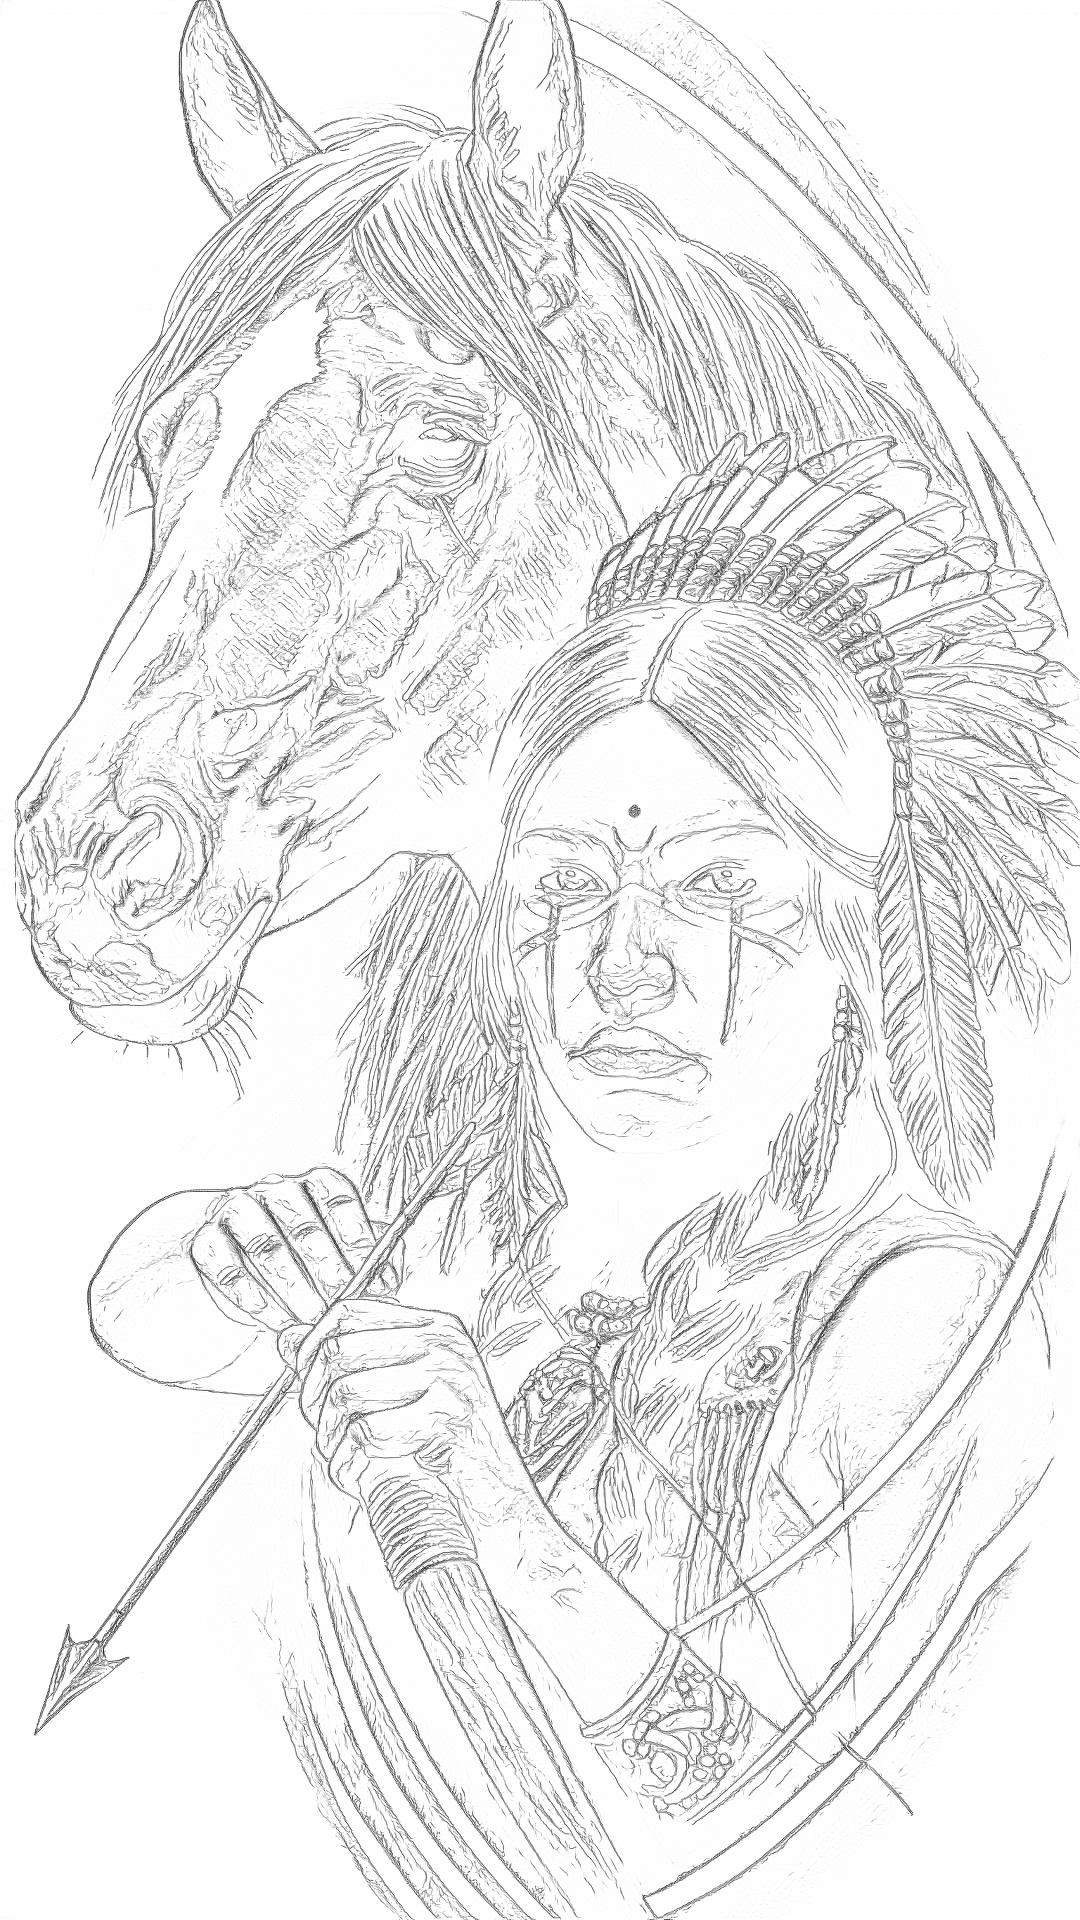

In [ ]:
# ============================================================
# CELL 6 — CURRENT SOURCE → DETAILED LINE CONFIDENCE
# SOURCE-ID LOCKED
#
# NO DIFFUSION
# NO DITHER
# NO SHADING
# NO GENERATIVE REDRAW
# ============================================================

source_path = find_single_source()

SOURCE_ID = source_fingerprint(
    source_path
)

with Image.open(
    source_path
) as opened:

    source_image = (
        ImageOps.exif_transpose(
            opened
        )
        .convert(
            "RGB"
        )
    )

source_width, source_height = (
    source_image.size
)

if (
    source_width < 32
    or source_height < 32
):

    raise RuntimeError(
        "SOURCE IMAGE IS TOO SMALL."
    )

# ------------------------------------------------------------
# REMOVE GENERIC DOWNSTREAM FILES FROM PREVIOUS SOURCE
# ------------------------------------------------------------

for stale_name in [

    "AI_Lineart_Detailed_Inverted.png",

    "Base_Lineart_Clean.png",

    "Base_Lineart_Violet.png",

    "Base_Lineart_Preview.png",

    "Violet_Lineart_Final.png",

    "Cell6_SourceID.txt",

    "Cell7_SourceID.txt",

]:

    stale_path = (
        OUTPUT_DIR
        / stale_name
    )

    if stale_path.exists():
        stale_path.unlink()

print(
    "=" * 72
)

print(
    "CELL 6 — RUNNING CURRENT SOURCE"
)

print(
    "=" * 72
)

print(
    "SOURCE:",
    source_path.name
)

print(
    "SOURCE ID:",
    SOURCE_ID
)

print(
    "SOURCE SIZE:",
    source_width,
    "x",
    source_height
)

# ------------------------------------------------------------
# REAL DETAILED LINEART DETECTOR
# ------------------------------------------------------------

try:

    with torch.inference_mode():

        detected = lineart_detector(

            source_image,

            coarse=False,

            detect_resolution=int(
                DETECT_RESOLUTION
            ),

            image_resolution=int(
                IMAGE_RESOLUTION
            ),

            output_type="pil",
        )

except torch.cuda.OutOfMemoryError as error:

    torch.cuda.empty_cache()

    raise RuntimeError(
        "GPU OUT OF MEMORY IN CELL 6.\n"
        "Do not automatically lower quality. "
        "Reduce DETECT_RESOLUTION manually if needed."
    ) from error

except Exception as error:

    raise RuntimeError(
        "REAL LINEART DETECTOR FAILED "
        "ON THE CURRENT SOURCE.\n"
        "No previous output was reused.\n\n"
        f"{type(error).__name__}: {error}"
    ) from error


if isinstance(
    detected,
    np.ndarray
):

    detected = Image.fromarray(
        detected
    )


if not isinstance(
    detected,
    Image.Image
):

    raise RuntimeError(
        "UNEXPECTED LINEART DETECTOR OUTPUT TYPE:\n"
        f"{type(detected)}"
    )


detected_gray = np.asarray(

    detected.convert(
        "L"
    ),

    dtype=np.uint8

).copy()

# ------------------------------------------------------------
# AUTOMATIC POLARITY
# DARK LINEWORK / WHITE BACKGROUND
# ------------------------------------------------------------

height, width = (
    detected_gray.shape
)

border = max(
    1,
    min(
        height,
        width
    ) // 40
)

border_pixels = np.concatenate(
    [

        detected_gray[
            :border,
            :
        ].reshape(-1),

        detected_gray[
            -border:,
            :
        ].reshape(-1),

        detected_gray[
            :,
            :border
        ].reshape(-1),

        detected_gray[
            :,
            -border:
        ].reshape(-1),

    ]
)

if float(
    border_pixels.mean()
) < 127.5:

    detected_gray = (
        255
        - detected_gray
    )

    polarity = (
        "INVERTED TO DARK LINES / WHITE BACKGROUND"
    )

else:

    polarity = (
        "ALREADY DARK LINES / WHITE BACKGROUND"
    )


# ------------------------------------------------------------
# EXACT ORIGINAL CANVAS SIZE
#
# One global resize only.
# No crop.
# No object movement.
# No local warp.
# ------------------------------------------------------------

if (
    detected_gray.shape[1]
    != source_width
    or
    detected_gray.shape[0]
    != source_height
):

    detected_gray = cv2.resize(

        detected_gray,

        (
            source_width,
            source_height
        ),

        interpolation=cv2.INTER_LANCZOS4
    )


source_specific_path = (

    OUTPUT_DIR
    / f"AI_Lineart_Detailed_Inverted_{SOURCE_ID}.png"

)

generic_path = (

    OUTPUT_DIR
    / "AI_Lineart_Detailed_Inverted.png"

)

Image.fromarray(
    detected_gray,
    mode="L"
).save(
    source_specific_path
)

Image.fromarray(
    detected_gray,
    mode="L"
).save(
    generic_path
)


(
    OUTPUT_DIR
    / "Cell6_SourceID.txt"
).write_text(

    SOURCE_ID,

    encoding="utf-8"
)


manifest = {

    "source_id":
        SOURCE_ID,

    "source_name":
        source_path.name,

    "source_width":
        source_width,

    "source_height":
        source_height,

    "cell6_output":
        str(
            source_specific_path
        ),
}


(
    OUTPUT_DIR
    / "Cell6_Manifest.json"
).write_text(

    json.dumps(
        manifest,
        indent=2
    ),

    encoding="utf-8"
)


print()

print(
    "=" * 72
)

print(
    "CELL 6 CONFIRMED: PASS"
)

print(
    "=" * 72
)

print(
    "POLARITY:",
    polarity
)

print(
    "OUTPUT SIZE:",
    detected_gray.shape[1],
    "x",
    detected_gray.shape[0]
)

print(
    "OLD OUTPUT REUSED: NO"
)

print(
    "CROP: NO"
)

print(
    "LOCAL WARP: NO"
)

print(
    "DIFFUSION REDRAW: NO"
)

print(
    "RANDOMNESS: NONE"
)

print(
    "OUTPUT:",
    generic_path
)

display(
    Image.fromarray(
        detected_gray,
        mode="L"
    )
)

In [ ]:
# ============================================================
# CELL 7 — COARSE-GUIDED CLEAN STRUCTURAL LINE ENGINE
#
# FIXES:
#   - connected photographic micro-texture
#   - excessive scratch lines
#   - over-dense horse/hair/skin detail
#
# REAL MODEL LOGIC:
#   Cell 6 detailed model = fine information
#   Real coarse model      = structural authority
#
# DEFAULT:
#   Darken     20
#   Contrast   38
#   Thickness   0
#   Cleanup     0
#
# NO DIFFUSION
# NO PROMPT
# NO GENERATIVE REDRAW
# NO RANDOMNESS
# ============================================================

import json
import numpy as np
import cv2
from PIL import Image, ImageOps
from IPython.display import display
import ipywidgets as widgets
import torch


# ------------------------------------------------------------
# 1. VERIFY CELLS 5–6
# ------------------------------------------------------------

required = [
    "OUTPUT_DIR",
    "lineart_detector",
    "find_single_source",
    "source_fingerprint",
    "DETECT_RESOLUTION",
    "IMAGE_RESOLUTION",
    "VIOLET_RGB",
    "SAFETY_BLUE_RGB",
    "BLACK_RGB"
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "CELL 7 CANNOT RUN.\n"
        "Missing objects from Cells 5–6:\n"
        + "\n".join(missing)
    )


# ------------------------------------------------------------
# 2. CURRENT SOURCE LOCK
# ------------------------------------------------------------

source_path = find_single_source()

SOURCE_ID = source_fingerprint(
    source_path
)

cell6_id_path = (
    OUTPUT_DIR
    / "Cell6_SourceID.txt"
)

detail_path = (
    OUTPUT_DIR
    / "AI_Lineart_Detailed_Inverted.png"
)

if not cell6_id_path.exists():
    raise RuntimeError(
        "Cell 6 source lock is missing. Run Cell 6 first."
    )

if not detail_path.exists():
    raise RuntimeError(
        "Cell 6 detailed lineart is missing. Run Cell 6 first."
    )

CELL6_ID = (
    cell6_id_path
    .read_text(
        encoding="utf-8"
    )
    .strip()
)

if SOURCE_ID != CELL6_ID:
    raise RuntimeError(
        "SOURCE CHANGED AFTER CELL 6.\n"
        "Run Cell 6 again before Cell 7."
    )


# ------------------------------------------------------------
# 3. LOAD CURRENT SOURCE
# ------------------------------------------------------------

with Image.open(
    source_path
) as opened:

    source_image = (
        ImageOps.exif_transpose(
            opened
        )
        .convert(
            "RGB"
        )
    )

source_w, source_h = (
    source_image.size
)


# ------------------------------------------------------------
# 4. LOAD CELL 6 DETAILED OUTPUT
# ------------------------------------------------------------

with Image.open(
    detail_path
) as opened:

    detail_gray = np.asarray(
        opened.convert("L"),
        dtype=np.uint8
    ).copy()

if detail_gray.shape != (
    source_h,
    source_w
):

    raise RuntimeError(
        "CELL 6 SIZE DOES NOT MATCH SOURCE.\n"
        f"Source: {(source_w, source_h)}\n"
        f"Cell 6: "
        f"{(detail_gray.shape[1], detail_gray.shape[0])}\n"
        "Run Cell 6 again."
    )


# ------------------------------------------------------------
# 5. RUN REAL COARSE LINEART MODEL
#
# This gives Cell 7 a cleaner structural authority.
# ------------------------------------------------------------

print("=" * 72)
print("CELL 7 — RUNNING REAL COARSE STRUCTURAL MODEL")
print("=" * 72)

print(
    "SOURCE:",
    source_path.name
)

print(
    "SOURCE ID:",
    SOURCE_ID
)

try:

    with torch.inference_mode():

        coarse = lineart_detector(
            source_image,
            coarse=True,
            detect_resolution=int(
                DETECT_RESOLUTION
            ),
            image_resolution=int(
                IMAGE_RESOLUTION
            ),
            output_type="pil"
        )

except Exception as error:

    raise RuntimeError(
        "REAL COARSE LINEART MODEL FAILED.\n"
        f"{type(error).__name__}: {error}"
    ) from error


if isinstance(
    coarse,
    np.ndarray
):

    coarse = Image.fromarray(
        coarse
    )


if not isinstance(
    coarse,
    Image.Image
):

    raise RuntimeError(
        "Unexpected coarse model output:\n"
        f"{type(coarse)}"
    )


coarse_gray = np.asarray(
    coarse.convert("L"),
    dtype=np.uint8
).copy()


# ------------------------------------------------------------
# 6. POLARITY GUARD
# ------------------------------------------------------------

border_size = max(
    1,
    min(
        coarse_gray.shape
    ) // 40
)

border_pixels = np.concatenate(
    [
        coarse_gray[
            :border_size,
            :
        ].ravel(),

        coarse_gray[
            -border_size:,
            :
        ].ravel(),

        coarse_gray[
            :,
            :border_size
        ].ravel(),

        coarse_gray[
            :,
            -border_size:
        ].ravel(),
    ]
)

if float(
    border_pixels.mean()
) < 127.5:

    coarse_gray = (
        255
        - coarse_gray
    )


# ------------------------------------------------------------
# 7. EXACT SOURCE CANVAS
# ------------------------------------------------------------

if coarse_gray.shape != (
    source_h,
    source_w
):

    coarse_gray = cv2.resize(
        coarse_gray,
        (
            source_w,
            source_h
        ),
        interpolation=cv2.INTER_LANCZOS4
    )


# Save coarse result for inspection.
coarse_path = (
    OUTPUT_DIR
    / f"AI_Lineart_Coarse_{SOURCE_ID}.png"
)

Image.fromarray(
    coarse_gray
).save(
    coarse_path,
    dpi=(300, 300)
)


# ------------------------------------------------------------
# 8. HELPERS
# ------------------------------------------------------------

def remove_small(
    mask01,
    minimum_area
):

    if minimum_area <= 1:
        return mask01.copy()

    count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mask01.astype(
                np.uint8
            ),
            connectivity=8
        )
    )

    kept = np.zeros_like(
        mask01,
        dtype=np.uint8
    )

    for label in range(
        1,
        count
    ):

        area = int(
            stats[
                label,
                cv2.CC_STAT_AREA
            ]
        )

        if area >= minimum_area:

            kept[
                labels == label
            ] = 1

    return kept


def directional_support(
    mask01
):

    source = mask01.astype(
        np.float32
    )

    kernels = [
        np.ones(
            (1, 5),
            dtype=np.float32
        ),

        np.ones(
            (5, 1),
            dtype=np.float32
        ),

        np.eye(
            5,
            dtype=np.float32
        ),

        np.fliplr(
            np.eye(
                5,
                dtype=np.float32
            )
        )
    ]

    responses = [

        cv2.filter2D(
            source,
            cv2.CV_32F,
            kernel,
            borderType=cv2.BORDER_CONSTANT
        )

        for kernel in kernels
    ]

    return np.maximum.reduce(
        responses
    )


def colorize(
    binary_bw,
    rgb
):

    output = np.full(
        (
            binary_bw.shape[0],
            binary_bw.shape[1],
            3
        ),
        255,
        dtype=np.uint8
    )

    output[
        binary_bw == 0
    ] = np.asarray(
        rgb,
        dtype=np.uint8
    )

    return output


# ------------------------------------------------------------
# 9. STRUCTURAL ENGINE
# ------------------------------------------------------------

def build_master(
    detail,
    coarse,
    darken,
    contrast,
    thickness,
    cleanup
):

    # Black line = high confidence.
    detailed_confidence = (
        1.0
        - detail.astype(
            np.float32
        )
        / 255.0
    )

    coarse_confidence = (
        1.0
        - coarse.astype(
            np.float32
        )
        / 255.0
    )

    darken_factor = (
        darken
        / 100.0
    )

    contrast_factor = (
        contrast
        / 100.0
    )

    cleanup_factor = (
        cleanup
        / 100.0
    )


    # --------------------------------------------------------
    # COARSE STRUCTURE THRESHOLD
    # --------------------------------------------------------

    coarse_threshold = float(
        np.clip(
            0.235
            - 0.055 * darken_factor
            + 0.015 * contrast_factor,
            0.14,
            0.32
        )
    )


    # --------------------------------------------------------
    # DETAILED LINE THRESHOLD
    # --------------------------------------------------------

    detail_threshold = float(
        np.clip(
            0.315
            - 0.060 * darken_factor
            + 0.035 * contrast_factor
            + 0.055 * cleanup_factor,
            0.20,
            0.46
        )
    )


    # --------------------------------------------------------
    # STRONG INDEPENDENT DETAIL
    #
    # Used for eyes, nose, mouth, jewelry, etc.
    # --------------------------------------------------------

    strong_threshold = float(
        np.clip(
            0.610
            - 0.045 * darken_factor
            + 0.060 * cleanup_factor,
            0.48,
            0.72
        )
    )


    # --------------------------------------------------------
    # PRIMARY STRUCTURE FROM REAL COARSE MODEL
    # --------------------------------------------------------

    coarse_mask = (
        coarse_confidence
        >= coarse_threshold
    ).astype(
        np.uint8
    )

    coarse_mask = remove_small(
        coarse_mask,
        3
    )


    # --------------------------------------------------------
    # DETAILED CANDIDATES
    # --------------------------------------------------------

    detail_candidate = (
        detailed_confidence
        >= detail_threshold
    ).astype(
        np.uint8
    )

    detail_strong = (
        detailed_confidence
        >= strong_threshold
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # LINE COHERENCE TEST
    #
    # Dots and random texture fail.
    # Continuous genuine strokes survive.
    # --------------------------------------------------------

    coherent_detail = (
        (
            detail_candidate
            == 1
        )
        &
        (
            directional_support(
                detail_candidate
            )
            >= 3.0
        )
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # COARSE SUPPORT ZONE
    #
    # Fine detail normally has to live near
    # genuine coarse structural geometry.
    # --------------------------------------------------------

    support_radius = max(
        2,
        min(
            4,
            int(
                round(
                    4
                    - 2
                    * cleanup_factor
                )
            )
        )
    )

    support_kernel = (
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                support_radius * 2 + 1,
                support_radius * 2 + 1
            )
        )
    )

    coarse_support = cv2.dilate(
        coarse_mask,
        support_kernel,
        iterations=1
    )

    near_coarse_detail = (
        (
            coherent_detail
            == 1
        )
        &
        (
            coarse_support
            == 1
        )
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # PRESERVE IMPORTANT STRONG DETAILS
    # EVEN WHEN COARSE MODEL MISSES THEM.
    # --------------------------------------------------------

    independent_detail = (
        (
            detail_strong
            == 1
        )
        &
        (
            directional_support(
                detail_strong
            )
            >= 2.0
        )
    ).astype(
        np.uint8
    )

    independent_detail = remove_small(
        independent_detail,
        int(
            round(
                5
                + 10
                * cleanup_factor
            )
        )
    )


    # --------------------------------------------------------
    # FINAL STRUCTURAL MASK
    # --------------------------------------------------------

    line_mask = np.maximum(
        coarse_mask,
        near_coarse_detail
    )

    line_mask = np.maximum(
        line_mask,
        independent_detail
    )


    # --------------------------------------------------------
    # THICKNESS
    #
    # NO automatic global thickening.
    # --------------------------------------------------------

    if thickness > 0:

        radius = int(
            thickness
        )

        kernel = (
            cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE,
                (
                    radius * 2 + 1,
                    radius * 2 + 1
                )
            )
        )

        line_mask = cv2.dilate(
            line_mask,
            kernel,
            iterations=1
        )


    elif thickness < 0:

        radius = abs(
            int(
                thickness
            )
        )

        kernel = (
            cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE,
                (
                    radius * 2 + 1,
                    radius * 2 + 1
                )
            )
        )

        line_mask = cv2.erode(
            line_mask,
            kernel,
            iterations=1
        )


    return np.where(
        line_mask == 1,
        0,
        255
    ).astype(
        np.uint8
    )


# ------------------------------------------------------------
# 10. REAL CONTROLS
# ------------------------------------------------------------

darken_slider = widgets.IntSlider(
    value=20,
    min=0,
    max=100,
    step=1,
    description="Darken",
    continuous_update=False,
    layout=widgets.Layout(
        width="520px"
    )
)

contrast_slider = widgets.IntSlider(
    value=38,
    min=0,
    max=100,
    step=1,
    description="Contrast",
    continuous_update=False,
    layout=widgets.Layout(
        width="520px"
    )
)

thickness_slider = widgets.IntSlider(
    value=0,
    min=-2,
    max=3,
    step=1,
    description="Thickness",
    continuous_update=False,
    layout=widgets.Layout(
        width="520px"
    )
)

cleanup_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=100,
    step=1,
    description="Cleanup",
    continuous_update=False,
    layout=widgets.Layout(
        width="520px"
    )
)

line_color = widgets.ToggleButtons(
    options=[
        (
            "Violet",
            "violet"
        ),
        (
            "Black",
            "black"
        ),
        (
            "Safety Blue",
            "blue"
        )
    ],
    value="violet",
    description="Line color"
)


clean_button = widgets.Button(
    description="Clean"
)

darker_button = widgets.Button(
    description="Darker"
)

bold_button = widgets.Button(
    description="Bold Lines"
)

reset_button = widgets.Button(
    description="Reset"
)

preview_output = (
    widgets.Output()
)

updating = False


# ------------------------------------------------------------
# 11. COLOR SELECTION
# ------------------------------------------------------------

def selected_rgb():

    if line_color.value == "black":
        return BLACK_RGB

    if line_color.value == "blue":
        return SAFETY_BLUE_RGB

    return VIOLET_RGB


# ------------------------------------------------------------
# 12. RENDER
# ------------------------------------------------------------

def render_current(
    *_
):

    if updating:
        return

    master = build_master(
        detail_gray,
        coarse_gray,
        darken_slider.value,
        contrast_slider.value,
        thickness_slider.value,
        cleanup_slider.value
    )

    preview_rgb = colorize(
        master,
        selected_rgb()
    )

    violet_rgb = colorize(
        master,
        VIOLET_RGB
    )


    source_master = (
        OUTPUT_DIR
        / f"Base_Lineart_Clean_{SOURCE_ID}.png"
    )

    source_violet = (
        OUTPUT_DIR
        / f"Base_Lineart_Violet_{SOURCE_ID}.png"
    )

    generic_master = (
        OUTPUT_DIR
        / "Base_Lineart_Clean.png"
    )

    generic_preview = (
        OUTPUT_DIR
        / "Base_Lineart_Preview.png"
    )

    generic_violet = (
        OUTPUT_DIR
        / "Base_Lineart_Violet.png"
    )


    Image.fromarray(
        master
    ).save(
        source_master,
        dpi=(300, 300)
    )

    Image.fromarray(
        master
    ).save(
        generic_master,
        dpi=(300, 300)
    )

    Image.fromarray(
        preview_rgb
    ).save(
        generic_preview,
        dpi=(300, 300)
    )

    Image.fromarray(
        violet_rgb
    ).save(
        source_violet,
        dpi=(300, 300)
    )

    Image.fromarray(
        violet_rgb
    ).save(
        generic_violet,
        dpi=(300, 300)
    )


    (
        OUTPUT_DIR
        / "Cell7_SourceID.txt"
    ).write_text(
        SOURCE_ID,
        encoding="utf-8"
    )


    settings = {
        "source_id":
            SOURCE_ID,

        "engine":
            "real_coarse_guided_detail_selector",

        "darken":
            darken_slider.value,

        "contrast":
            contrast_slider.value,

        "thickness_px":
            thickness_slider.value,

        "cleanup":
            cleanup_slider.value,

        "violet_rgb":
            list(
                VIOLET_RGB
            )
    }


    (
        OUTPUT_DIR
        / "Cell7_Settings.json"
    ).write_text(
        json.dumps(
            settings,
            indent=2
        ),
        encoding="utf-8"
    )


    with preview_output:

        preview_output.clear_output(
            wait=True
        )

        print(
            f"Darken {darken_slider.value}% | "
            f"Contrast {contrast_slider.value}% | "
            f"Thickness {thickness_slider.value:+d}px | "
            f"Cleanup {cleanup_slider.value}%"
        )

        print(
            "ENGINE: REAL COARSE STRUCTURE + SELECTIVE DETAIL"
        )

        print(
            "SOURCE ID:",
            SOURCE_ID
        )

        display(
            Image.fromarray(
                preview_rgb
            )
        )


# ------------------------------------------------------------
# 13. PRESETS
# ------------------------------------------------------------

def set_controls(
    darken,
    contrast,
    thickness,
    cleanup
):

    global updating

    updating = True

    darken_slider.value = (
        darken
    )

    contrast_slider.value = (
        contrast
    )

    thickness_slider.value = (
        thickness
    )

    cleanup_slider.value = (
        cleanup
    )

    updating = False

    render_current()


def clean_preset(_):

    set_controls(
        20,
        38,
        0,
        0
    )


def darker_preset(_):

    set_controls(
        30,
        34,
        0,
        0
    )


def bold_preset(_):

    set_controls(
        22,
        38,
        1,
        0
    )


def reset_preset(_):

    set_controls(
        20,
        38,
        0,
        0
    )

    line_color.value = (
        "violet"
    )


clean_button.on_click(
    clean_preset
)

darker_button.on_click(
    darker_preset
)

bold_button.on_click(
    bold_preset
)

reset_button.on_click(
    reset_preset
)


for control in [
    darken_slider,
    contrast_slider,
    thickness_slider,
    cleanup_slider,
    line_color
]:

    control.observe(
        render_current,
        names="value"
    )


# ------------------------------------------------------------
# 14. PANEL
# ------------------------------------------------------------

display(
    widgets.VBox(
        [
            widgets.HTML(
                "<h3>Line adjustments</h3>"
                "<b>Coarse-guided structural cleanup</b>"
            ),

            widgets.HBox(
                [
                    clean_button,
                    darker_button,
                    bold_button
                ]
            ),

            darken_slider,
            contrast_slider,
            thickness_slider,
            cleanup_slider,
            line_color,
            reset_button,
            preview_output
        ]
    )
)


# First render
render_current()


print()
print("=" * 72)
print("CELL 7 CONFIRMED: PASS")
print("=" * 72)

print(
    "REAL COARSE STRUCTURAL GATE: YES"
)

print(
    "REAL DETAILED INPUT: YES"
)

print(
    "CONNECTED MICRO-TEXTURE FILTER: YES"
)

print(
    "AUTOMATIC GLOBAL THICKENING: NO"
)

print(
    "SOURCE LOCK: PASS"
)

print(
    "DIFFUSION: NO"
)

print(
    "DITHER: NO"
)

print(
    "RANDOMNESS: NONE"
)

CELL 7 — RUNNING REAL COARSE STRUCTURAL MODEL
SOURCE: IMG_2022.JPG
SOURCE ID: 997e85158bd50c22



CELL 7 CONFIRMED: PASS
REAL COARSE STRUCTURAL GATE: YES
REAL DETAILED INPUT: YES
CONNECTED MICRO-TEXTURE FILTER: YES
AUTOMATIC GLOBAL THICKENING: NO
SOURCE LOCK: PASS
DIFFUSION: NO
DITHER: NO
RANDOMNESS: NONE


CELL 8 CONFIRMED: PASS
SOURCE ID: 997e85158bd50c22
SOURCE SIZE: (1080, 1920)
FINAL SIZE: (1080, 1920)
SOURCE MATCH: PASS
RESIZE IN CELL 8: NO
CROP: NO
SHADING: NONE
DITHER: NONE
GRAYSCALE IN FINAL: NONE
FINAL COLORS: WHITE + #9B4DFF ONLY
FINAL FILE: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/output/Violet_Lineart_Final.png


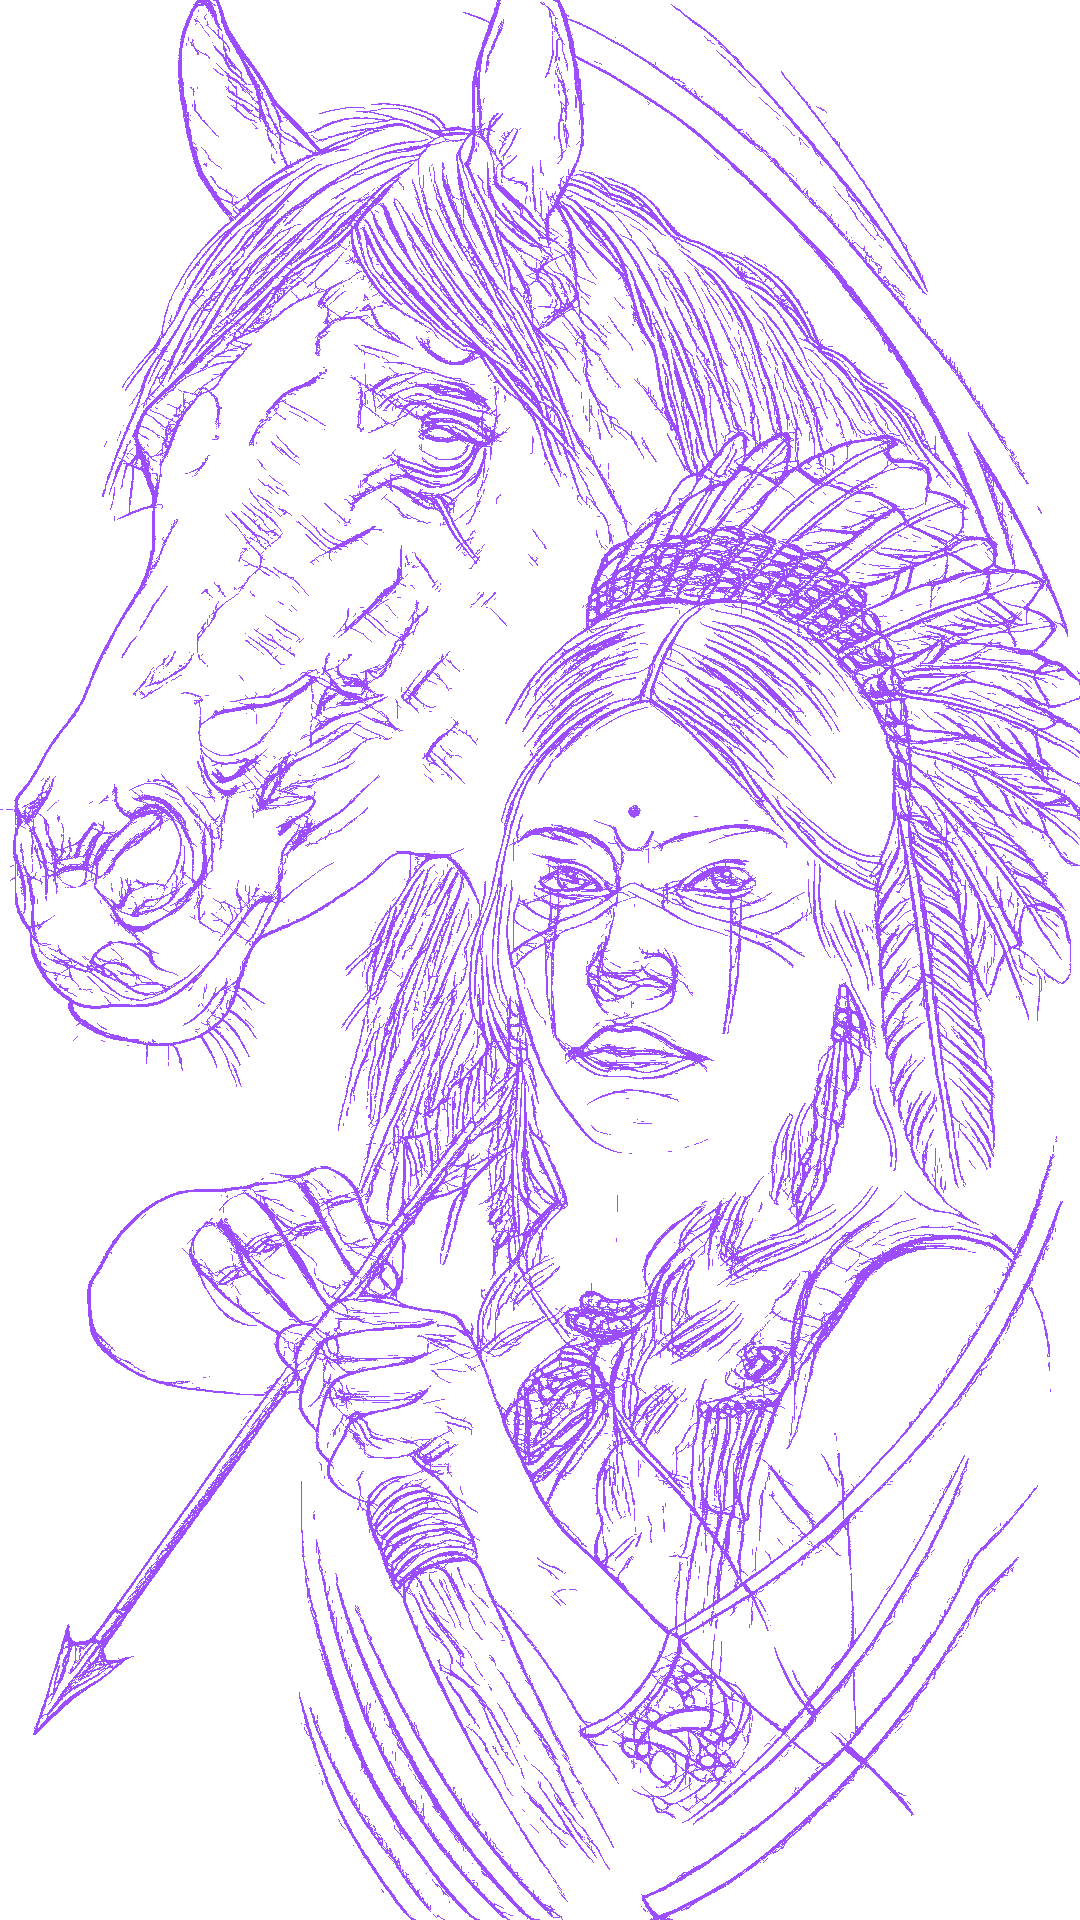

In [ ]:
# ============================================================
# CELL 8 — FINAL SOURCE-LOCKED VIOLET EXPORT
# PURE #9B4DFF + PURE WHITE ONLY
# ============================================================

from PIL import Image
import numpy as np

current_source_path = find_single_source()
CURRENT_SOURCE_ID = source_fingerprint(
    current_source_path
)

cell6_id_path = (
    OUTPUT_DIR
    / "Cell6_SourceID.txt"
)

cell7_id_path = (
    OUTPUT_DIR
    / "Cell7_SourceID.txt"
)

if not cell6_id_path.exists():
    raise RuntimeError(
        "Cell 6 source lock is missing. Run Cell 6."
    )

if not cell7_id_path.exists():
    raise RuntimeError(
        "Cell 7 source lock is missing. Run Cell 7."
    )

CELL6_SOURCE_ID = (
    cell6_id_path
    .read_text(
        encoding="utf-8"
    )
    .strip()
)

CELL7_SOURCE_ID = (
    cell7_id_path
    .read_text(
        encoding="utf-8"
    )
    .strip()
)

if not (
    CURRENT_SOURCE_ID
    == CELL6_SOURCE_ID
    == CELL7_SOURCE_ID
):

    raise RuntimeError(
        "SOURCE MISMATCH DETECTED.\n"
        "Run Cell 6 -> Cell 7 -> Cell 8 "
        "on the current source."
    )

master_path = (
    OUTPUT_DIR
    / f"Base_Lineart_Clean_{CURRENT_SOURCE_ID}.png"
)

if not master_path.exists():

    raise RuntimeError(
        "Source-specific Cell 7 master is missing. "
        "Run Cell 7 again."
    )

with Image.open(
    current_source_path
) as source_opened:

    source_size = (
        source_opened.size
    )

with Image.open(
    master_path
) as master_opened:

    master = np.asarray(
        master_opened.convert("L"),
        dtype=np.uint8
    ).copy()

final_size = (
    master.shape[1],
    master.shape[0]
)

if final_size != source_size:

    raise RuntimeError(
        "FINAL GEOMETRY SIZE MISMATCH.\n"
        f"Source: {source_size}\n"
        f"Lineart: {final_size}\n"
        "Stopping instead of resizing."
    )

master = np.where(
    master < 128,
    0,
    255
).astype(
    np.uint8
)

final_violet = np.full(
    (
        master.shape[0],
        master.shape[1],
        3
    ),
    255,
    dtype=np.uint8
)

final_violet[
    master == 0
] = np.asarray(
    VIOLET_RGB,
    dtype=np.uint8
)

source_specific_final = (
    OUTPUT_DIR
    / f"Violet_Lineart_Final_{CURRENT_SOURCE_ID}.png"
)

generic_final = (
    OUTPUT_DIR
    / "Violet_Lineart_Final.png"
)

Image.fromarray(
    final_violet
).save(
    source_specific_final,
    format="PNG",
    dpi=(300, 300)
)

Image.fromarray(
    final_violet
).save(
    generic_final,
    format="PNG",
    dpi=(300, 300)
)

unique_colors = np.unique(
    final_violet.reshape(
        -1,
        3
    ),
    axis=0
)

actual_colors = {
    tuple(
        map(
            int,
            row
        )
    )
    for row in unique_colors
}

allowed_colors = {
    (
        255,
        255,
        255
    ),
    tuple(
        VIOLET_RGB
    )
}

if not actual_colors.issubset(
    allowed_colors
):

    raise RuntimeError(
        "FINAL COLOR VERIFICATION FAILED."
    )

print("=" * 72)
print("CELL 8 CONFIRMED: PASS")
print("=" * 72)
print(
    "SOURCE ID:",
    CURRENT_SOURCE_ID
)
print(
    "SOURCE SIZE:",
    source_size
)
print(
    "FINAL SIZE:",
    final_size
)
print("SOURCE MATCH: PASS")
print("RESIZE IN CELL 8: NO")
print("CROP: NO")
print("SHADING: NONE")
print("DITHER: NONE")
print("GRAYSCALE IN FINAL: NONE")
print(
    "FINAL COLORS: WHITE + #9B4DFF ONLY"
)
print(
    "FINAL FILE:",
    generic_final
)

display(
    Image.fromarray(
        final_violet
    )
)

CELL 9 CONFIRMED: PASS
SOURCE ID: 997e85158bd50c22
GEOMETRY CHANGED FROM CELL 7: NO
BLACK VALUE: 0
WHITE VALUE: 255
GRAY PIXELS: NONE
DITHER: NONE
SHADING: NONE
DPI METADATA: 300
THERMAL FILE: /content/drive/MyDrive/SkinGraphicsPro_ControlNet/output/Thermal_Black_Master_300DPI.png


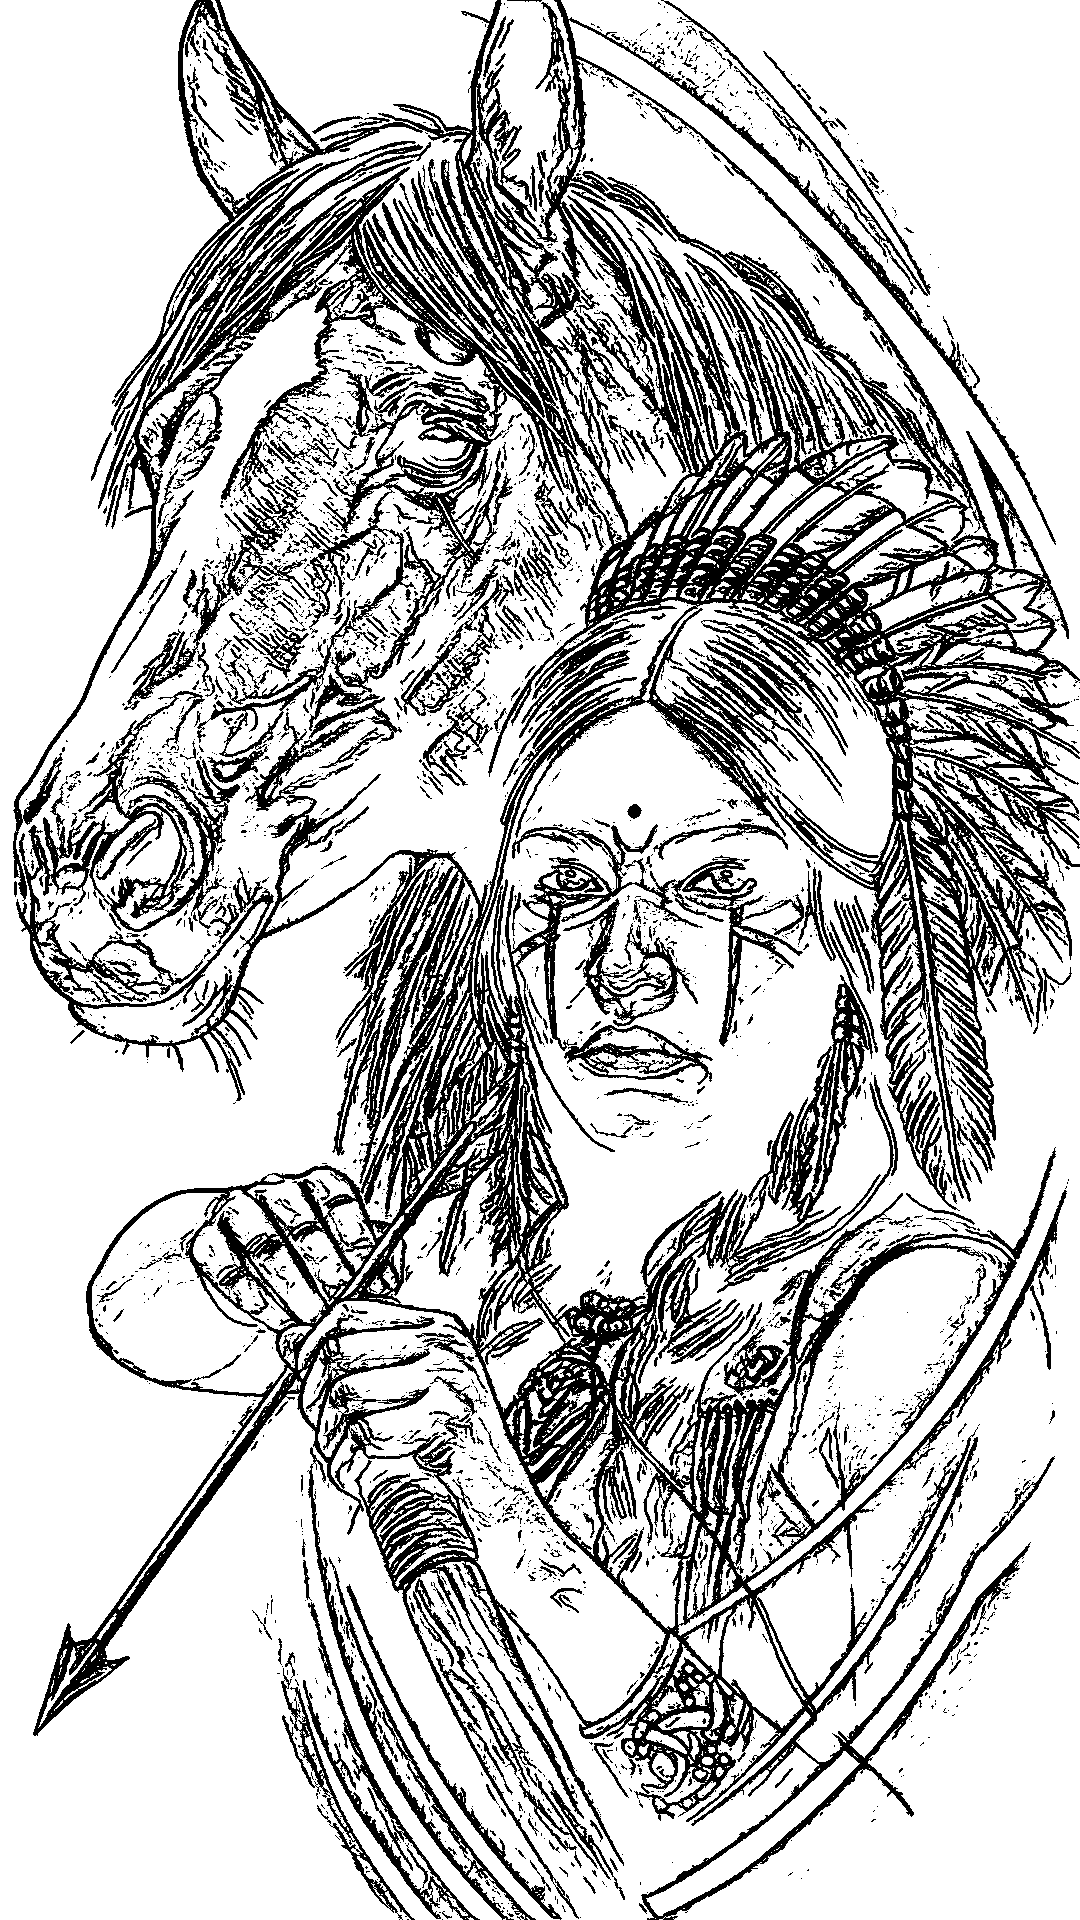

In [ ]:
# ============================================================
# CELL 9 — THERMAL / THERMOFAX BLACK MASTER
# SAME GEOMETRY AS CELL 8
#
# PURE BLACK = 0
# PURE WHITE = 255
# 300 DPI
#
# NO DITHER
# NO SHADING
# NO GEOMETRY CHANGE
# ============================================================

from PIL import Image
import numpy as np

current_source_path = find_single_source()

CURRENT_SOURCE_ID = source_fingerprint(
    current_source_path
)

cell7_id_path = (
    OUTPUT_DIR
    / "Cell7_SourceID.txt"
)

if not cell7_id_path.exists():

    raise RuntimeError(
        "Cell 7 source lock is missing. "
        "Run Cell 7 first."
    )

CELL7_SOURCE_ID = (
    cell7_id_path
    .read_text(
        encoding="utf-8"
    )
    .strip()
)

if CURRENT_SOURCE_ID != CELL7_SOURCE_ID:

    raise RuntimeError(
        "SOURCE MISMATCH DETECTED.\n"
        "Run Cell 6 -> Cell 7 before Cell 9."
    )

master_path = (
    OUTPUT_DIR
    / f"Base_Lineart_Clean_{CURRENT_SOURCE_ID}.png"
)

if not master_path.exists():

    raise RuntimeError(
        "Source-specific black master is missing. "
        "Run Cell 7."
    )

with Image.open(
    master_path
) as opened:

    master = np.asarray(
        opened.convert("L"),
        dtype=np.uint8
    ).copy()

thermal_bw = np.where(
    master < 128,
    0,
    255
).astype(
    np.uint8
)

thermal_path = (
    OUTPUT_DIR
    / f"Thermal_Black_Master_300DPI_{CURRENT_SOURCE_ID}.png"
)

generic_thermal_path = (
    OUTPUT_DIR
    / "Thermal_Black_Master_300DPI.png"
)

Image.fromarray(
    thermal_bw
).save(
    thermal_path,
    format="PNG",
    dpi=(300, 300)
)

Image.fromarray(
    thermal_bw
).save(
    generic_thermal_path,
    format="PNG",
    dpi=(300, 300)
)

unique_values = set(
    map(
        int,
        np.unique(
            thermal_bw
        )
    )
)

if not unique_values.issubset(
    {
        0,
        255
    }
):

    raise RuntimeError(
        "THERMAL OUTPUT IS NOT STRICT BLACK/WHITE."
    )

print("=" * 72)
print("CELL 9 CONFIRMED: PASS")
print("=" * 72)
print(
    "SOURCE ID:",
    CURRENT_SOURCE_ID
)
print(
    "GEOMETRY CHANGED FROM CELL 7: NO"
)
print("BLACK VALUE: 0")
print("WHITE VALUE: 255")
print("GRAY PIXELS: NONE")
print("DITHER: NONE")
print("SHADING: NONE")
print("DPI METADATA: 300")
print(
    "THERMAL FILE:",
    generic_thermal_path
)

display(
    Image.fromarray(
        thermal_bw
    )
)